# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:
- Email:
- Id Dicoding:

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
# Menghilangkan pesan warning yang mengganggu
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('../employee_data.csv')

## Data Understanding

Tahap ini bertujuan untuk memahami karakteristik *dataset*, mendeteksi *missing values* atau duplikat, dan mengeksplorasi data (EDA) untuk menemukan pola. Berdasarkan informasi *dataset*, kita memiliki 34 kolom yang berisi demografi, metrik pekerjaan, dan target variabel `Attrition` (0=No, 1=Yes).

### Pengecekan Informasi Dataset
melihat struktur data, ukuran *dataset*, tipe data, dan statistik deskriptif awal.

In [15]:
display(df.head())

print("\nINFORMASI DATASET:")
df.info()

print(f"\nUkuran Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



INFORMASI DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   i

### Pengecekan Missing Value dan Duplikat
Dari `df.head()` sebelumnya, terlihat ada nilai `NaN` pada kolom target `Attrition`. Mari kita cek secara keseluruhan berapa banyak *missing values* dan apakah ada baris yang terduplikasi.

In [16]:
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

Jumlah Missing Values per Kolom:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLif

### Exploratory Data Analysis (EDA)

#### Distribusi Variabel Target (Attrition)
Kita perlu melihat distribusi jumlah karyawan yang bertahan (`0.0`) dan karyawan yang keluar (`1.0`). Untuk visualisasi ini, kita akan mengabaikan sementara data yang kosong (`NaN`).

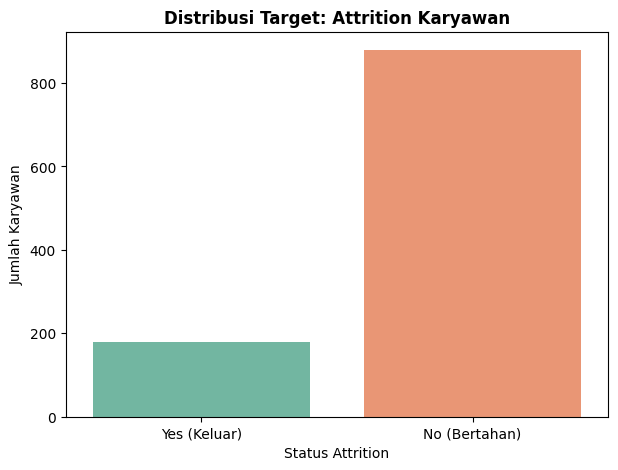

Persentase Attrition:
- No (Bertahan): 83.08%
- Yes (Keluar): 16.92%


In [18]:
df_eda = df.dropna(subset=['Attrition']).copy()

df_eda['Attrition_Label'] = df_eda['Attrition'].map({0.0: 'No (Bertahan)', 1.0: 'Yes (Keluar)'})

plt.figure(figsize=(7, 5))
sns.countplot(x='Attrition_Label', data=df_eda, palette='Set2')
plt.title('Distribusi Target: Attrition Karyawan', fontweight='bold')
plt.xlabel('Status Attrition')
plt.ylabel('Jumlah Karyawan')
plt.show()

print("Persentase Attrition:")
attrition_counts = df_eda['Attrition_Label'].value_counts(normalize=True) * 100
for index, value in attrition_counts.items():
    print(f"- {index}: {value:.2f}%")

#### Analisis Korelasi Fitur Numerik terhadap Attrition
Untuk mengidentifikasi faktor apa saja yang paling memicu tingginya angka *attrition*, kita akan melihat nilai korelasi antara fitur numerik di dalam dataset dengan kolom target `Attrition`.

Top 10 Fitur Paling Berkorelasi dengan Attrition:

TotalWorkingYears         -0.177137
Age                       -0.172067
JobLevel                  -0.169201
StockOptionLevel          -0.164228
MonthlyIncome             -0.163600
YearsInCurrentRole        -0.158757
YearsWithCurrManager      -0.155962
JobInvolvement            -0.150196
YearsAtCompany            -0.135134
EnvironmentSatisfaction   -0.132848
Name: Attrition, dtype: float64


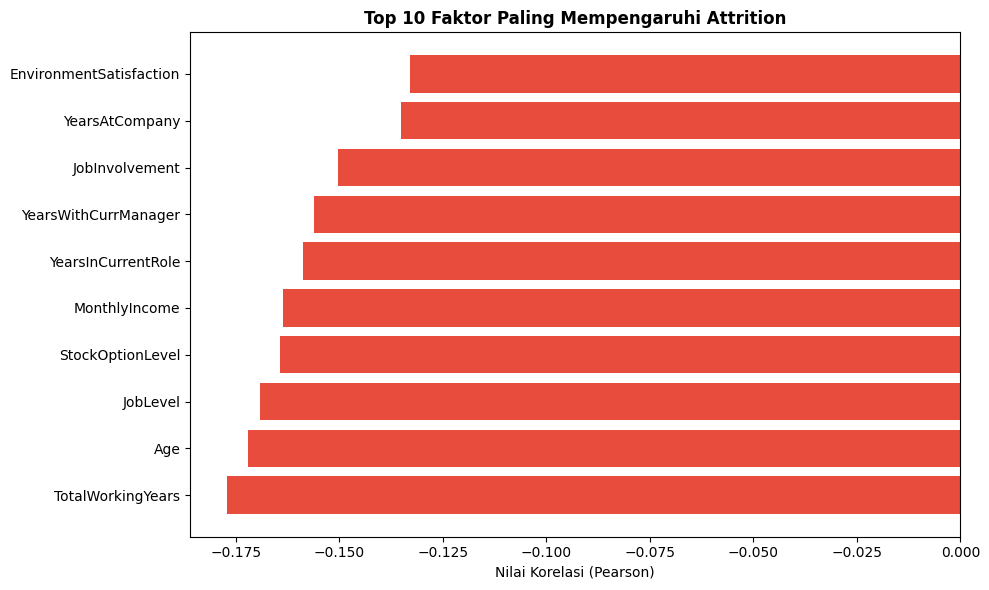

In [20]:
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()

if 'EmployeeId' in numeric_cols:
    numeric_cols.remove('EmployeeId')
if 'EmployeeCount' in numeric_cols:
    numeric_cols.remove('EmployeeCount') # Nilainya sama semua (1), tidak berguna untuk korelasi
if 'Attrition' in numeric_cols:
    numeric_cols.remove('Attrition')

correlations = df_eda[numeric_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

print("Top 10 Fitur Paling Berkorelasi dengan Attrition:\n")
print(correlations.head(10))

# Visualisasi Korelasi
plt.figure(figsize=(10, 6))
top_10_corr = correlations.head(10).sort_values()
colors = ['#e74c3c' if x < 0 else '#3498db' for x in top_10_corr.values]

plt.barh(range(len(top_10_corr)), top_10_corr.values, color=colors)
plt.yticks(range(len(top_10_corr)), top_10_corr.index)
plt.xlabel('Nilai Korelasi (Pearson)')
plt.title('Top 10 Faktor Paling Mempengaruhi Attrition', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

Tahap ini berfokus pada pembersihan dan transformasi data agar siap digunakan. Proses ini dibagi menjadi dua jalur:

### Persiapan Data untuk Dashboard (Metabase)
Untuk kebutuhan *dashboard*, kita akan membuat salinan data (`df_dash`), menghapus baris yang nilai *Attrition*-nya kosong, dan mengubah nilai numerik (1, 2, 3, 4) menjadi label kategori (Low, Medium, High) agar grafik lebih mudah dipahami.

In [ ]:
df_dash = df.copy()

df_dash = df_dash.dropna(subset=['Attrition'])

satisfaction_map = {1: '1 - Low', 2: '2 - Medium', 3: '3 - High', 4: '4 - Very High'}
wlb_map = {1: '1 - Bad', 2: '2 - Good', 3: '3 - Better', 4: '4 - Best'}

kolom_satisfaction = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
for col in kolom_satisfaction:
    if col in df_dash.columns:
        df_dash[col] = pd.to_numeric(df_dash[col], errors='coerce').map(satisfaction_map)

if 'WorkLifeBalance' in df_dash.columns:
    df_dash['WorkLifeBalance'] = pd.to_numeric(df_dash['WorkLifeBalance'], errors='coerce').map(wlb_map)

# Memastikan Attrition bernilai Yes/No (dari 1.0/0.0)
if 'Attrition' in df_dash.columns:
    df_dash['Attrition'] = df_dash['Attrition'].replace({1.0: 'Yes', 0.0: 'No'})

# Memastikan OverTime bernilai Yes/No
if 'OverTime' in df_dash.columns:
    df_dash['OverTime'] = df_dash['OverTime'].replace({'Yes': 'Yes', 'No': 'No', 'true': 'Yes', 'false': 'No'})

# Mengekspor data bersih ke CSV
df_dash.to_csv('employee_data_clean.csv', index=False)
print(f"Data dashboard siap! Diekspor ke 'employee_data_clean.csv' dengan total {len(df_dash)} baris.")

Data dashboard siap! Diekspor ke 'employee_data_clean.csv' dengan total 1058 baris.


### Penanganan Missing Values (Untuk Modeling)
Sekarang kita kembali ke *dataset* asli (`df`) yang akan digunakan untuk pemodelan. Model *Machine Learning* tidak dapat memproses nilai `NaN`. Oleh karena itu, kita akan menghapus baris target yang kosong dan mengisi *missing values* pada fitur numerik (jika ada) dengan nilai rata-rata (*mean*).

In [24]:
df = df.dropna(subset=['Attrition'])

df['Attrition'] = df['Attrition'].astype(int)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print(f"Jumlah baris setelah pembersihan data untuk modeling: {len(df)}")

Jumlah baris setelah pembersihan data untuk modeling: 1058


### Encoding Fitur Kategorikal
Algoritma *Machine Learning* memerlukan input berupa angka. Oleh karena itu, fitur yang berisi teks (seperti `Department`, `JobRole`, `Gender`) akan diubah menjadi format numerik menggunakan `LabelEncoder`.

In [29]:
from sklearn.preprocessing import LabelEncoder
import joblib
import os

# Membuat folder 'model' untuk menyimpan file .pkl
os.makedirs('model', exist_ok=True)

label_encoders = {}
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Proses Encoding
for col in categorical_features:
    le = LabelEncoder()
    # Menangani baris kosong pada data kategorikal jika ada
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Menyimpan encoder untuk digunakan pada script prediksi nanti
joblib.dump(label_encoders, 'model/label_encoders.pkl')
print("Encoding kategorikal selesai dan berhasil disimpan!")

Encoding kategorikal selesai dan berhasil disimpan!


### Pembagian Data Latih dan Uji (Train-Test Split)
Kita membagi *dataset* menjadi dua bagian: 80% untuk melatih model (*Training Data*) dan 20% untuk menguji performa model (*Testing Data*). Fitur target (y) adalah `Attrition`, dan sisanya adalah fitur prediktor (X). Kolom `EmployeeId` dan `EmployeeCount` akan dihapus karena tidak relevan untuk prediksi.

In [30]:
from sklearn.model_selection import train_test_split

# Mendefinisikan X dan y
cols_to_drop = ['Attrition', 'EmployeeId', 'EmployeeCount']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['Attrition']

# Splitting data (80:20) dengan stratify agar proporsi target seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Test): {X_test.shape[0]} baris")

Jumlah Data Latih (Train): 846 baris
Jumlah Data Uji (Test): 212 baris


### Feature Scaling (Normalisasi)
Fitur numerik sering kali memiliki skala yang berbeda-beda (misalnya `Age` berkisar puluhan, sedangkan `MonthlyIncome` ribuan). Kita menggunakan `StandardScaler` untuk menyamakan skala fitur-fitur ini, sehingga algoritma dapat belajar lebih optimal dan tidak bias pada fitur dengan angka besar.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Melakukan normalisasi pada X_train dan X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Menyimpan scaler untuk digunakan pada script prediksi nanti
joblib.dump(scaler, 'model/scaler.pkl')
print("Feature scaling selesai dan scaler berhasil disimpan!")

Feature scaling selesai dan scaler berhasil disimpan!


## Modeling

Pada tahap pemodelan ini, kita akan menggunakan algoritma **Logistic Regression**. Algoritma ini dipilih karena sangat efisien, mudah diinterpretasikan probabilitasnya, dan berkinerja baik untuk masalah klasifikasi biner (*binary classification*) seperti memprediksi apakah seorang karyawan akan keluar (1) atau bertahan (0).

### Melatih Model Logistic Regression
Kita akan melatih model menggunakan data latih (`X_train_scaled` dan `y_train`) yang sudah disiapkan pada tahap sebelumnya.

In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)

# Melatih model menggunakan data latih
model.fit(X_train_scaled, y_train)

# Menyimpan model yang sudah dilatih ke dalam folder 'model'
joblib.dump(model, 'model/trained_model.pkl')

print("Model Logistic Regression berhasil dilatih dan disimpan sebagai 'trained_model.pkl'")

Model Logistic Regression berhasil dilatih dan disimpan sebagai 'trained_model.pkl'


## Evaluation

Setelah model dilatih, tahap selanjutnya adalah mengevaluasi kinerjanya menggunakan data uji (`X_test_scaled` dan `y_test`). Evaluasi ini penting untuk memastikan model dapat memprediksi dengan akurat pada data yang belum pernah dilihat sebelumnya.

Metrik evaluasi yang akan kita gunakan meliputi:
1. **Accuracy**: Persentase total prediksi yang benar.
2. **Classification Report**: Menampilkan *Precision*, *Recall*, dan *F1-Score* untuk setiap kelas.
3. **Confusion Matrix**: Menampilkan jumlah *True Positives*, *True Negatives*, *False Positives*, dan *False Negatives*.
4. **ROC-AUC Score**: Mengukur kemampuan model dalam membedakan antara karyawan yang keluar dan bertahan.

Accuracy Score: 0.8585 (85.85%)

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.89      0.94      0.92       176
  Keluar (1)       0.62      0.44      0.52        36

    accuracy                           0.86       212
   macro avg       0.75      0.69      0.72       212
weighted avg       0.85      0.86      0.85       212

ROC-AUC Score: 0.8078



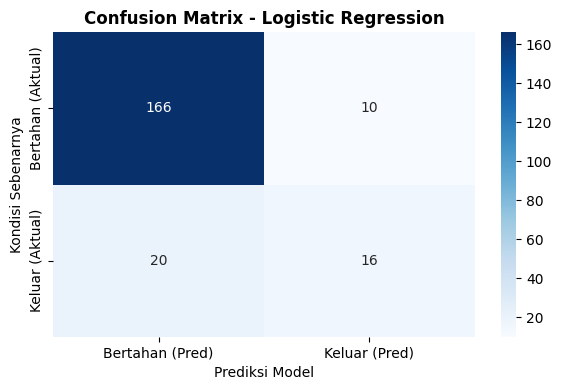

In [34]:
# Melakukan prediksi menggunakan data uji
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilitas untuk kelas positif (Keluar)

# 1. Menghitung Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

# 2. Menampilkan Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Bertahan (0)', 'Keluar (1)']))

# 3. Menghitung ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 4. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bertahan (Pred)', 'Keluar (Pred)'], 
            yticklabels=['Bertahan (Aktual)', 'Keluar (Aktual)'])
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.tight_layout()
plt.show()